In [13]:

import os

print(os.listdir("../data/data/raw/apnea-ecg"))

['a01.apn', 'a01.dat', 'a01.hea', 'a01.qrs', 'a02.dat']


In [14]:
%pip install numpy pandas matplotlib scikit-learn wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully


In [15]:
import wfdb

record = wfdb.rdrecord("../data/data/raw/apnea-ecg/a01")

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Channels:", record.sig_name)

Signal shape: (2957000, 1)
Sampling frequency: 100
Channels: ['ECG']


In [16]:
ecg = record.p_signal[:, 0]

print("ECG shape:", ecg.shape)
print("First 10 samples:")
print(ecg[:10])

ECG shape: (2957000,)
First 10 samples:
[-0.06  -0.065 -0.06  -0.075 -0.065 -0.07  -0.07  -0.09  -0.08  -0.095]


In [18]:
fs = record.fs

print("Sampling frequency:", fs)

Sampling frequency: 100


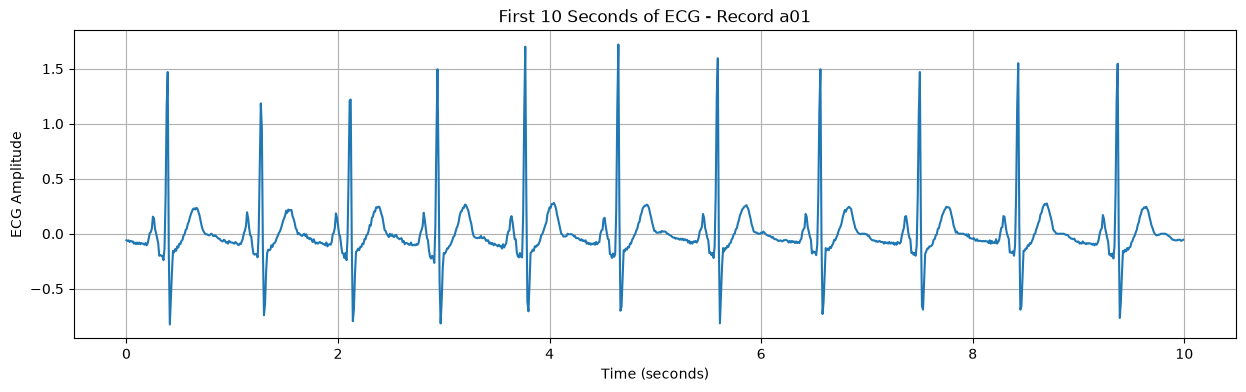

In [19]:
seconds = 10

samples = int(seconds * fs)

plt.figure(figsize=(15, 4))

plt.plot(
    np.arange(samples) / fs,
    ecg[:samples]
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("First 10 Seconds of ECG - Record a01")
plt.grid()

plt.show()

In [22]:

import wfdb

annotation = wfdb.rdann("../data/data/raw/apnea-ecg/a01", "apn")

print("Number of annotations:", len(annotation.sample))

print("First 20 annotation samples:")
print(annotation.sample[:20])

print("First 20 symbols:")
print(annotation.symbol[:20])


Number of annotations: 489
First 20 annotation samples:
[     0   6000  12000  18000  24000  30000  36000  42000  48000  54000
  60000  66000  72000  78000  84000  90000  96000 102000 108000 114000]
First 20 symbols:
['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'A', 'A', 'A', 'A', 'A', 'A']


In [23]:
print("Sampling frequency:", record.fs)

print("\nFirst 20 annotation samples:")
print(annotation.sample[:20])

print("\nFirst 20 annotation times (seconds):")
print(annotation.sample[:20] / record.fs)

print("\nFirst 20 annotation symbols:")
print(annotation.symbol[:20])

Sampling frequency: 100

First 20 annotation samples:
[     0   6000  12000  18000  24000  30000  36000  42000  48000  54000
  60000  66000  72000  78000  84000  90000  96000 102000 108000 114000]

First 20 annotation times (seconds):
[   0.   60.  120.  180.  240.  300.  360.  420.  480.  540.  600.  660.
  720.  780.  840.  900.  960. 1020. 1080. 1140.]

First 20 annotation symbols:
['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'A', 'A', 'A', 'A', 'A', 'A']


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ECG signal already loaded in 'record'
ecg = record.p_signal[:, 0]
fs = record.fs

print("Sampling frequency:", fs)
print("Number of samples:", len(ecg))

# Remove DC offset
ecg_centered = ecg - np.mean(ecg)

print("Original mean:", np.mean(ecg))
print("Mean after centering:", np.mean(ecg_centered))

Sampling frequency: 100
Number of samples: 2957000
Original mean: 0.0005639279675346633
Mean after centering: -1.275949248186044e-18


In [25]:
# Moving average window
window_seconds = 0.8
window = int(window_seconds * fs)

# Make sure window is odd
if window % 2 == 0:
    window += 1

# Estimate baseline
baseline = np.convolve(
    ecg_centered,
    np.ones(window) / window,
    mode='same'
)

# Remove baseline
ecg_detrended = ecg_centered - baseline

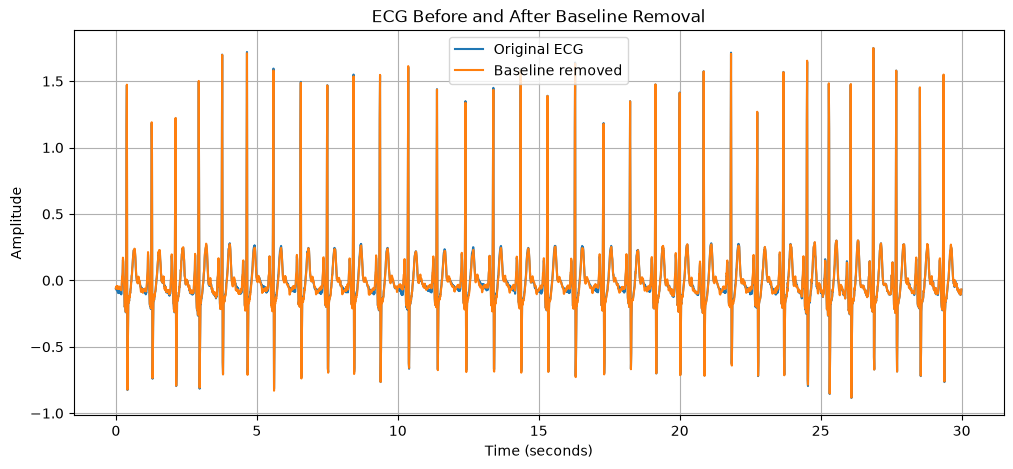

In [26]:
duration = 30
samples = int(duration * fs)

time = np.arange(samples) / fs

plt.figure(figsize=(12, 5))

plt.plot(time, ecg_centered[:samples], label="Original ECG")
plt.plot(time, ecg_detrended[:samples], label="Baseline removed")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Before and After Baseline Removal")
plt.legend()
plt.grid()
plt.show()

In [27]:
# Low-pass moving average
lp_window_seconds = 0.08
lp_window = int(lp_window_seconds * fs)

if lp_window < 1:
    lp_window = 1

ecg_filtered = np.convolve(
    ecg_detrended,
    np.ones(lp_window) / lp_window,
    mode='same'
)

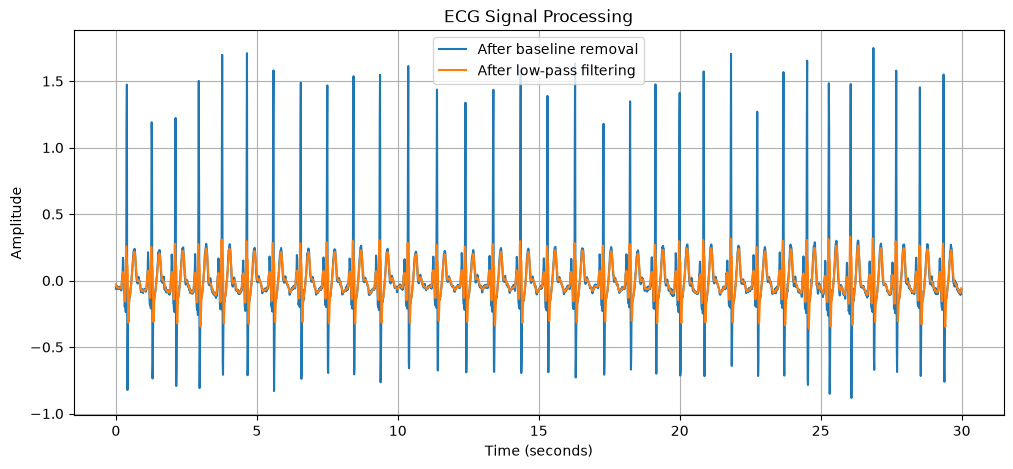

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(time, ecg_detrended[:samples], label="After baseline removal")
plt.plot(time, ecg_filtered[:samples], label="After low-pass filtering")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal Processing")
plt.legend()
plt.grid()
plt.show()

In [29]:
# R-peak detection using threshold + minimum distance

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# Use the filtered ECG
signal = ecg_filtered

# Minimum distance between two heartbeats
# At least 0.5 seconds apart -> maximum ~120 BPM
min_distance = int(0.5 * fs)

# Set threshold based on the signal
threshold = np.mean(signal) + 0.5 * np.std(signal)

# Detect peaks
peaks, properties = find_peaks(
    signal,
    height=threshold,
    distance=min_distance
)

print("Number of detected R-peaks:", len(peaks))
print("First 20 R-peak samples:")
print(peaks[:20])

print("\nFirst 20 R-peak times (seconds):")
print(peaks[:20] / fs)

Number of detected R-peaks: 29820
First 20 R-peak samples:
[  37  126  210  292  375  463  557  654  748  841  935 1035 1137 1238
 1337 1434 1529 1627 1728 1822]

First 20 R-peak times (seconds):
[ 0.37  1.26  2.1   2.92  3.75  4.63  5.57  6.54  7.48  8.41  9.35 10.35
 11.37 12.38 13.37 14.34 15.29 16.27 17.28 18.22]


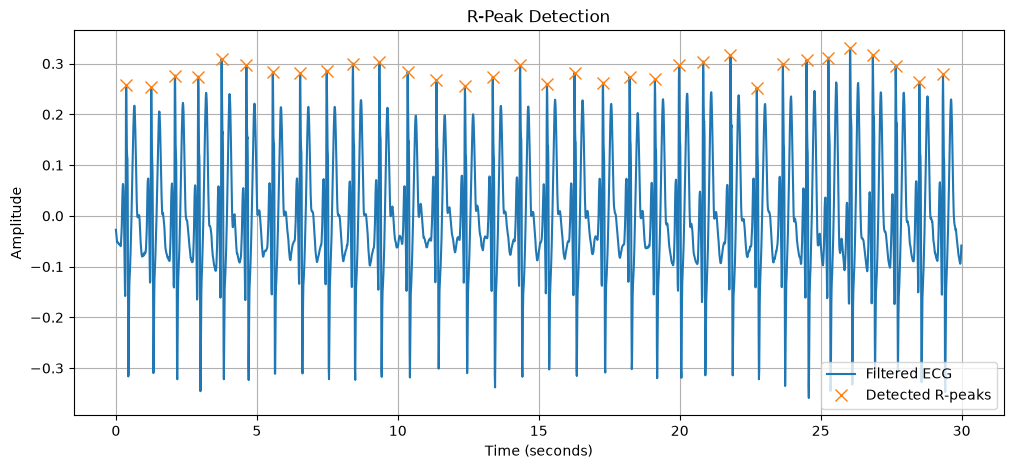

In [30]:
# Plot detected R-peaks over ECG

duration = 30
samples = int(duration * fs)

time = np.arange(samples) / fs

plt.figure(figsize=(12, 5))

plt.plot(time, signal[:samples], label="Filtered ECG")

# Only peaks within first 30 seconds
visible_peaks = peaks[peaks < samples]

plt.plot(
    visible_peaks / fs,
    signal[visible_peaks],
    "x",
    markersize=8,
    label="Detected R-peaks"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("R-Peak Detection")
plt.legend()
plt.grid()
plt.show()

In [31]:
# Calculate RR intervals

rr_intervals = np.diff(peaks) / fs

print("Number of RR intervals:", len(rr_intervals))

print("\nFirst 20 RR intervals (seconds):")
print(rr_intervals[:20])

Number of RR intervals: 29819

First 20 RR intervals (seconds):
[0.89 0.84 0.82 0.83 0.88 0.94 0.97 0.94 0.93 0.94 1.   1.02 1.01 0.99
 0.97 0.95 0.98 1.01 0.94 0.9 ]


In [32]:
# Calculate instantaneous heart rate

heart_rate = 60 / rr_intervals

print("First 20 heart-rate values:")
print(heart_rate[:20], "BPM")

First 20 heart-rate values:
[67.41573034 71.42857143 73.17073171 72.28915663 68.18181818 63.82978723
 61.8556701  63.82978723 64.51612903 63.82978723 60.         58.82352941
 59.40594059 60.60606061 61.8556701  63.15789474 61.2244898  59.40594059
 63.82978723 66.66666667] BPM


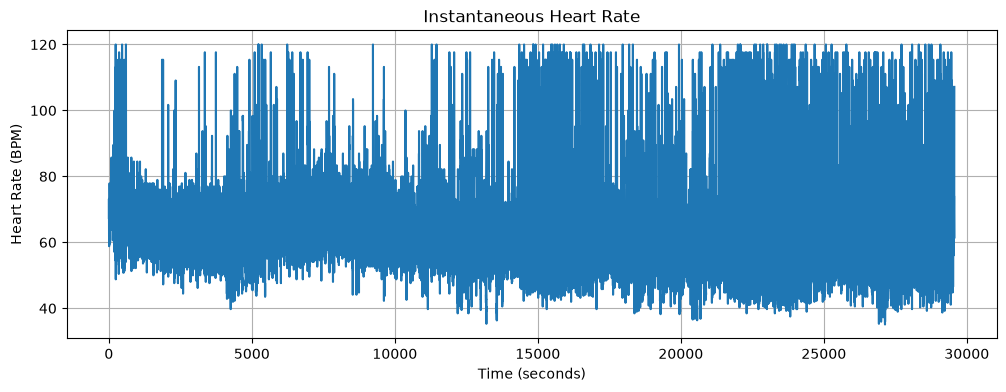

In [33]:
# Time corresponding to each RR interval
rr_time = peaks[1:] / fs

plt.figure(figsize=(12, 4))

plt.plot(rr_time, heart_rate)

plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Instantaneous Heart Rate")
plt.grid()
plt.show()